In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [10]:
DATA = np.zeros((5, 3))  # Creates a 5x3 array filled with zeros

# Manually setting values
#
# the first column is the number of infected contact ferrets for H1N1
# the second column and third columns are the numbers of infected contact ferrets for H3N2 (per replicate with 4 ferrets) and -99 means missing
#
# total number of contact ferrets in each experiment is 4
#
DATA[0] = [4, 3, 2]     # infectious dose is 10^6
DATA[1] = [4, 4, -99]   # infectious dose is 10^4
DATA[2] = [4, 2, -99]   # infectious dose is 10^2
DATA[3] = [4, 1, -99]   # infectious dose is 10^1
DATA[4] = [3, 0, -99]   # infectious dose is 10^0   

print( DATA )

print( DATA[3,2] )


[[  4.   3.   2.]
 [  4.   4. -99.]
 [  4.   2. -99.]
 [  4.   1. -99.]
 [  3.   0. -99.]]
-99.0


In [11]:
def compute_nonparam_statistic( D ):

    nr = D.shape[0] # number of rows

    test_statistic = 0

    # add up all of the H1N1 infected contact ferrets
    for r in range(nr):
        if( D[r,0] > -1 ):
            test_statistic = test_statistic + D[r,0]

    # subtract off all of the H3N2 infected ferrets in column 1
    for r in range(nr):
        if( D[r,1] > -1 ):
            test_statistic = test_statistic - D[r,1]

    # subtract off all of the H3N2 infected ferrets in column 2
    for r in range(nr):
        if( D[r,2] > -1 ):
            test_statistic = test_statistic - D[r,2]

    return test_statistic



In [12]:
print( compute_nonparam_statistic(DATA))


7.0


In [13]:
N = 100000
output = np.zeros(N)

# these are the indices that will be permuted for the rows
r12 = np.array([0,1])
r123 = np.array([0,1,2])

for i in range(N):

    Z = DATA.copy()

    y = np.random.permutation(r123)
    Z[0,0] = DATA[0,y[0]]
    Z[0,1] = DATA[0,y[1]]
    Z[0,2] = DATA[0,y[2]]

    x = np.random.permutation(r12)
    Z[1,0] = DATA[1,x[0]]
    Z[1,1] = DATA[1,x[1]]

    x = np.random.permutation(r12)
    Z[2,0] = DATA[2,x[0]]
    Z[2,1] = DATA[2,x[1]]

    x = np.random.permutation(r12)
    Z[3,0] = DATA[3,x[0]]
    Z[3,1] = DATA[3,x[1]]

    x = np.random.permutation(r12)
    Z[4,0] = DATA[4,x[0]]
    Z[4,1] = DATA[4,x[1]]

    output[i] = compute_nonparam_statistic( Z )


In [14]:

print(output.shape)
    
print(DATA)

print( max(output) )

(100000,)
[[  4.   3.   2.]
 [  4.   4. -99.]
 [  4.   2. -99.]
 [  4.   1. -99.]
 [  3.   0. -99.]]
7.0


[-12.5 -11.5 -10.5  -9.5  -8.5  -7.5  -6.5  -5.5  -4.5  -3.5  -2.5  -1.5
  -0.5   0.5   1.5   2.5   3.5   4.5   5.5   6.5   7.5]
[-13. -12. -11. -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.   0.
   1.   2.   3.   4.   5.   6.   7.]


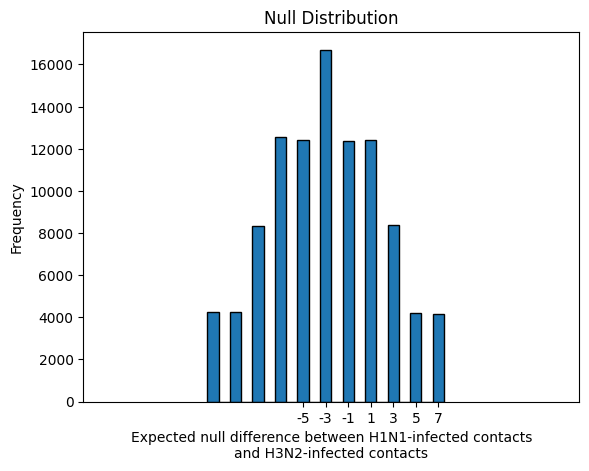

In [15]:
# Plot histogram
bins = np.arange(output.min(), output.max() + 2)
plt.hist(output, bins=bins, edgecolor='black', align='mid')
bin_centers = (bins[:-1] + bins[1:]) / 2 
plt.xticks([-4.5, -2.5, -0.5, 1.5, 3.5, 5.5, 7.5],['-5','-3','-1','1','3','5','7'])

# Labels
plt.xlabel("Expected null difference between H1N1-infected contacts\nand H3N2-infected contacts")
plt.ylabel("Frequency")
plt.title("Null Distribution")
plt.xlim(-24, 20)

print( bin_centers )
print( bins[:-1] )

In [16]:
print( "p value is", sum(output>=7) / N ) 


p value is 0.04146
